In [1]:
# Install the libraries required by the RiverMind project.
# Run this cell once in VS Code.

%pip install pandas requests geopandas folium branca matplotlib numpy openpyxl

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
# Import all libraries used in the notebook

import pandas as pd
import requests
import geopandas as gpd
import folium
import branca
import matplotlib.pyplot as plt
import numpy as np

from datetime import datetime, timedelta
from pathlib import Path
from IPython.display import display
from matplotlib.patches import Patch

import os
import re
import json
import warnings

warnings.filterwarnings("ignore")

# Display settings
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 120)
pd.set_option("display.max_colwidth", 40)

# Set the RiverMind project folder
PROJECT_FOLDER = Path(r"C:\Users\Aadya\OneDrive\Desktop\rainfall_prediction")

# Create required folders
DATA_FOLDER = PROJECT_FOLDER / "data"
RAINFALL_FOLDER = DATA_FOLDER / "rainfall"
OUTPUT_FOLDER = PROJECT_FOLDER / "outputs"

RAINFALL_FOLDER.mkdir(parents=True, exist_ok=True)
OUTPUT_FOLDER.mkdir(parents=True, exist_ok=True)

# File paths
RAINFALL_HISTORY_FILE = RAINFALL_FOLDER / "assam_rainfall_history.csv"
DISTRICT_OUTPUT_FILE = DATA_FOLDER / "district_flood_dataset.csv"
TODAY_DATASET_FILE = OUTPUT_FOLDER / "flood_risk_dataset_today.csv"
SUMMARY_FILE = OUTPUT_FOLDER / "flood_summary_today.xlsx"
HTML_MAP_FILE = OUTPUT_FOLDER / "assam_flood_zoning_map.html"
PNG_MAP_FILE = OUTPUT_FOLDER / "assam_flood_zoning_map.png"

# Required flood-zone colors
SAFE_COLOR = "#A7D8FF"
MEDIUM_COLOR = "#CDB4DB"
HIGH_COLOR = "#D63384"

ZONE_COLORS = {
    "Safe": SAFE_COLOR,
    "Medium Risk": MEDIUM_COLOR,
    "High Risk": HIGH_COLOR
}

# Automatically get today's date
TODAY = datetime.now().strftime("%Y-%m-%d")

print("RiverMind project folder:", PROJECT_FOLDER)
print("Data folder:", DATA_FOLDER)
print("Rainfall folder:", RAINFALL_FOLDER)
print("Output folder:", OUTPUT_FOLDER)
print("Today's date:", TODAY)

RiverMind project folder: C:\Users\Aadya\OneDrive\Desktop\rainfall_prediction
Data folder: C:\Users\Aadya\OneDrive\Desktop\rainfall_prediction\data
Rainfall folder: C:\Users\Aadya\OneDrive\Desktop\rainfall_prediction\data\rainfall
Output folder: C:\Users\Aadya\OneDrive\Desktop\rainfall_prediction\outputs
Today's date: 2026-09-28


In [3]:
# Locate the district Excel file.
# The preferred filename is Assam_35_Districts_FloodRisk_with_Rivers.xlsx.
# The code also supports .xls and .xlsx extensions.

possible_files = [
    PROJECT_FOLDER / "Assam_35_Districts_FloodRisk_with_Rivers.xlsx",
    PROJECT_FOLDER / "Assam_35_Districts_FloodRisk_with_Rivers.xls",
    PROJECT_FOLDER / "assam_district_dataset.xlsx",
    PROJECT_FOLDER / "assam_district_dataset.xls"
]

district_file = None

for file_path in possible_files:
    if file_path.exists():
        district_file = file_path
        break

if district_file is None:
    matching_files = list(PROJECT_FOLDER.glob("Assam_35_Districts_FloodRisk_with_Rivers*.xlsx"))
    matching_files += list(PROJECT_FOLDER.glob("Assam_35_Districts_FloodRisk_with_Rivers*.xls"))
    
    if len(matching_files) > 0:
        district_file = matching_files[0]

if district_file is None:
    raise FileNotFoundError(
        "District Excel file was not found. Place the Excel dataset in the same folder "
        "as this notebook."
    )

# Read the Excel dataset
district_df = pd.read_excel(district_file)

# Clean column names
district_df.columns = [str(column).strip() for column in district_df.columns]

# Support both possible river column names
if "Closest_River" not in district_df.columns and "Nearest_River" in district_df.columns:
    district_df["Closest_River"] = district_df["Nearest_River"]

# Remove accidental spaces from district names
district_df["District"] = district_df["District"].astype(str).str.strip()

print("Dataset file:", district_file.name)
print("\nFirst five rows:")
display(district_df.head())

print("\nColumn names:")
print(list(district_df.columns))

print("\nNumber of rows:", len(district_df))
print("Number of unique districts:", district_df["District"].nunique())

if district_df["District"].nunique() == 35:
    print("Verification successful: 35 Assam districts found.")
else:
    print("Warning: the dataset does not contain exactly 35 unique districts.")

required_columns = [
    "District",
    "Latitude",
    "Longitude",
    "Elevation_m",
    "Closest_River",
    "Distance_to_River_km"
]

missing_columns = [
    column for column in required_columns
    if column not in district_df.columns
]

if missing_columns:
    raise ValueError("Missing required columns: " + str(missing_columns))

Dataset file: Assam_35_Districts_FloodRisk_with_Rivers.xlsx

First five rows:


,District,Latitude,Longitude,Elevation_m,Nearest_River,Distance_to_River_km,River_Type,Closest_River
0,Bajali,26.4994,91.1793,43,Pagladia River,5,North Bank Tributary,Pagladia River
1,Baksa,26.6620,91.3411,52,Manas River,8,North Bank Tributary,Manas River
2,Barpeta,26.3200,91.0000,35,Brahmaputra River,12,Main Stem,Brahmaputra River
3,Biswanath,26.7258,93.1466,69,Brahmaputra River,15,Main Stem,Brahmaputra River
4,Bongaigaon,26.4769,90.5583,63,Brahmaputra River,10,Main Stem,Brahmaputra River



Column names:
['District', 'Latitude', 'Longitude', 'Elevation_m', 'Nearest_River', 'Distance_to_River_km', 'River_Type', 'Closest_River']

Number of rows: 35
Number of unique districts: 35
Verification successful: 35 Assam districts found.


In [6]:
# CELL 4 — Fetch daily rainfall using Open-Meteo API
#
# Open-Meteo does not require an API key.
# It provides precipitation forecasts and historical weather data.
#
# We use:
# precipitation_sum = total daily precipitation in millimetres
#
# For flood monitoring, precipitation_sum is used as daily rainfall.
#
# The API is queried once for every Assam district using the
# latitude and longitude from the Excel dataset.

OPEN_METEO_API = "https://api.open-meteo.com/v1/forecast"

def normalize_district_name(name):
    """
    Standardize district names for matching.
    """
    if pd.isna(name):
        return ""
    
    name = str(name).strip().lower()
    
    replacements = {
        "district": "",
        "&": "and",
        "–": "-",
        "—": "-",
        "_": " ",
        ".": "",
        ",": ""
    }
    
    for old_value, new_value in replacements.items():
        name = name.replace(old_value, new_value)
    
    name = re.sub(r"\s+", " ", name).strip()
    
    aliases = {
        "kamrup metropolitan": "kamrup metro",
        "kamrup metropolitan district": "kamrup metro",
        "sribhumi": "karimganj",
        "sri bhumi": "karimganj"
    }
    
    return aliases.get(name, name)


def fetch_open_meteo_rainfall():
    """
    Fetch today's rainfall for all Assam districts.
    """
    output_columns = [
        "District",
        "Date",
        "Rainfall_mm",
        "Normal_Rainfall_mm",
        "Departure_Percent"
    ]
    
    rainfall_records = []
    
    print("Fetching today's rainfall from Open-Meteo...")
    
    for _, district_row in district_df.iterrows():
        district_name = district_row["District"]
        latitude = district_row["Latitude"]
        longitude = district_row["Longitude"]
        
        try:
            latitude = float(latitude)
            longitude = float(longitude)
        except:
            print(
                f"Invalid coordinates for {district_name}. "
                "Rainfall will be stored as NA."
            )
            
            rainfall_records.append({
                "District": district_name,
                "Date": TODAY,
                "Rainfall_mm": np.nan,
                "Normal_Rainfall_mm": np.nan,
                "Departure_Percent": np.nan
            })
            
            continue
        
        parameters = {
            "latitude": latitude,
            "longitude": longitude,
            "daily": "precipitation_sum",
            "timezone": "Asia/Kolkata",
            "forecast_days": 1,
            "past_days": 0
        }
        
        try:
            response = requests.get(
                OPEN_METEO_API,
                params=parameters,
                timeout=30,
                headers={
                    "User-Agent": "RiverMind Assam Flood Monitoring Project"
                }
            )
            
            response.raise_for_status()
            weather_data = response.json()
            
            daily_data = weather_data.get("daily", {})
            dates = daily_data.get("time", [])
            precipitation_values = daily_data.get(
                "precipitation_sum",
                []
            )
            
            if len(dates) == 0 or len(precipitation_values) == 0:
                rainfall_value = np.nan
                date_value = TODAY
            else:
                date_value = dates[0]
                rainfall_value = precipitation_values[0]
            
            rainfall_records.append({
                "District": district_name,
                "Date": date_value,
                "Rainfall_mm": rainfall_value,
                "Normal_Rainfall_mm": np.nan,
                "Departure_Percent": np.nan
            })
            
        except requests.exceptions.Timeout:
            print(f"Timeout while requesting {district_name}.")
            
            rainfall_records.append({
                "District": district_name,
                "Date": TODAY,
                "Rainfall_mm": np.nan,
                "Normal_Rainfall_mm": np.nan,
                "Departure_Percent": np.nan
            })
        
        except requests.exceptions.ConnectionError:
            print(f"Internet error while requesting {district_name}.")
            
            rainfall_records.append({
                "District": district_name,
                "Date": TODAY,
                "Rainfall_mm": np.nan,
                "Normal_Rainfall_mm": np.nan,
                "Departure_Percent": np.nan
            })
        
        except requests.exceptions.RequestException as error:
            print(f"API error for {district_name}: {error}")
            
            rainfall_records.append({
                "District": district_name,
                "Date": TODAY,
                "Rainfall_mm": np.nan,
                "Normal_Rainfall_mm": np.nan,
                "Departure_Percent": np.nan
            })
        
        except Exception as error:
            print(f"Unexpected error for {district_name}: {error}")
            
            rainfall_records.append({
                "District": district_name,
                "Date": TODAY,
                "Rainfall_mm": np.nan,
                "Normal_Rainfall_mm": np.nan,
                "Departure_Percent": np.nan
            })
    
    rainfall_df = pd.DataFrame(
        rainfall_records,
        columns=output_columns
    )
    
    rainfall_df["Date"] = pd.to_datetime(
        rainfall_df["Date"],
        errors="coerce"
    ).dt.strftime("%Y-%m-%d")
    
    rainfall_df["Date"] = rainfall_df["Date"].fillna(TODAY)
    
    rainfall_df["Rainfall_mm"] = pd.to_numeric(
        rainfall_df["Rainfall_mm"],
        errors="coerce"
    )
    
    return rainfall_df


# Fetch rainfall for all 35 districts.
today_rainfall_df = fetch_open_meteo_rainfall()

print("\nRainfall records received:", len(today_rainfall_df))

if not today_rainfall_df.empty:
    display(today_rainfall_df)
else:
    print("Rainfall data is unavailable.")

# Check for missing districts.
excel_districts = set(
    district_df["District"].dropna().astype(str).str.strip()
)

api_districts = set(
    today_rainfall_df["District"].dropna().astype(str).str.strip()
)

missing_from_api = sorted(excel_districts - api_districts)
extra_in_api = sorted(api_districts - excel_districts)

print("\nDistricts missing from Open-Meteo results:")
print(
    missing_from_api
    if missing_from_api
    else "None"
)

print("\nDistricts returned but not present in Excel:")
print(
    extra_in_api
    if extra_in_api
    else "None"
)

print("\nOutput columns:")
print(list(today_rainfall_df.columns))

Fetching today's rainfall from Open-Meteo...
API error for Nagaon: 503 Server Error: Service Unavailable for url: https://api.open-meteo.com/v1/forecast?latitude=26.3504&longitude=92.6796&daily=precipitation_sum&timezone=Asia%2FKolkata&forecast_days=1&past_days=0

Rainfall records received: 35


,District,Date,Rainfall_mm,Normal_Rainfall_mm,Departure_Percent
0,Bajali,2026-09-28,1.2,NaN,NaN
1,Baksa,2026-09-28,0.5,NaN,NaN
2,Barpeta,2026-09-28,0.9,NaN,NaN
3,Biswanath,2026-09-28,0.5,NaN,NaN
4,Bongaigaon,2026-09-28,0.2,NaN,NaN
5,Cachar,2026-09-28,0.3,NaN,NaN
6,Charaideo,2026-09-28,4.1,NaN,NaN
7,Chirang,2026-09-28,0.2,NaN,NaN
8,Darrang,2026-09-28,0.2,NaN,NaN
9,Dhemaji,2026-09-28,7.8,NaN,NaN



Districts missing from Open-Meteo results:
None

Districts returned but not present in Excel:
None

Output columns:
['District', 'Date', 'Rainfall_mm', 'Normal_Rainfall_mm', 'Departure_Percent']


In [7]:
# CELL 5 — Update Rainfall History Automatically
#
# This cell stores today's Open-Meteo rainfall and keeps previous days.
# If today's district values already exist, they are replaced.
# Missing rainfall values remain as NA.

history_columns = [
    "District",
    "Date",
    "Rainfall_mm",
    "Normal_Rainfall_mm",
    "Departure_Percent"
]

# Read previous history if it exists.
if RAINFALL_HISTORY_FILE.exists():
    rainfall_history_df = pd.read_csv(
        RAINFALL_HISTORY_FILE
    )
else:
    rainfall_history_df = pd.DataFrame(
        columns=history_columns
    )

# Make sure all required columns exist.
for column in history_columns:
    if column not in rainfall_history_df.columns:
        rainfall_history_df[column] = np.nan

rainfall_history_df = rainfall_history_df[
    history_columns
].copy()

# Clean previous history.
rainfall_history_df["District"] = (
    rainfall_history_df["District"]
    .astype(str)
    .str.strip()
)

rainfall_history_df["Date"] = pd.to_datetime(
    rainfall_history_df["Date"],
    errors="coerce"
).dt.strftime("%Y-%m-%d")

for column in [
    "Rainfall_mm",
    "Normal_Rainfall_mm",
    "Departure_Percent"
]:
    rainfall_history_df[column] = pd.to_numeric(
        rainfall_history_df[column],
        errors="coerce"
    )

# Open-Meteo normally returns all districts.
# This merge guarantees that every Excel district is stored,
# even if one API request failed.
today_complete_df = district_df[
    ["District"]
].copy()

today_complete_df["Date"] = TODAY

today_complete_df = today_complete_df.merge(
    today_rainfall_df,
    on=["District", "Date"],
    how="left"
)

today_complete_df = today_complete_df[
    history_columns
]

# Remove old records for today's date.
rainfall_history_df = rainfall_history_df[
    rainfall_history_df["Date"] != TODAY
].copy()

# Add the refreshed values for today.
rainfall_history_df = pd.concat(
    [
        rainfall_history_df,
        today_complete_df
    ],
    ignore_index=True
)

# Prevent duplicate district-date combinations.
rainfall_history_df = rainfall_history_df.drop_duplicates(
    subset=["District", "Date"],
    keep="last"
)

# Sort and save the rainfall history.
rainfall_history_df = rainfall_history_df.sort_values(
    ["Date", "District"]
).reset_index(drop=True)

rainfall_history_df.to_csv(
    RAINFALL_HISTORY_FILE,
    index=False,
    na_rep=""
)

print("Rainfall history updated successfully.")
print("Saved to:", RAINFALL_HISTORY_FILE)
print("Total history rows:", len(rainfall_history_df))

display(
    rainfall_history_df[
        rainfall_history_df["Date"] == TODAY
    ]
)

Rainfall history updated successfully.
Saved to: C:\Users\Aadya\OneDrive\Desktop\rainfall_prediction\data\rainfall\assam_rainfall_history.csv
Total history rows: 35


,District,Date,Rainfall_mm,Normal_Rainfall_mm,Departure_Percent
0,Bajali,2026-09-28,1.2,NaN,NaN
1,Baksa,2026-09-28,0.5,NaN,NaN
2,Barpeta,2026-09-28,0.9,NaN,NaN
3,Biswanath,2026-09-28,0.5,NaN,NaN
4,Bongaigaon,2026-09-28,0.2,NaN,NaN
5,Cachar,2026-09-28,0.3,NaN,NaN
6,Charaideo,2026-09-28,4.1,NaN,NaN
7,Chirang,2026-09-28,0.2,NaN,NaN
8,Darrang,2026-09-28,0.2,NaN,NaN
9,Dhemaji,2026-09-28,7.8,NaN,NaN


In [8]:
# CELL 6 — Merge Rainfall with District Dataset

# Select today's rainfall records.
today_rainfall_for_merge = rainfall_history_df[
    rainfall_history_df["Date"] == TODAY
].copy()

# Merge today's rainfall with the district Excel data.
merged_df = district_df.merge(
    today_rainfall_for_merge,
    on="District",
    how="left"
)

# Keep districts even when rainfall is unavailable.
merged_df["Date"] = merged_df["Date"].fillna(TODAY)

for column in [
    "Rainfall_mm",
    "Normal_Rainfall_mm",
    "Departure_Percent"
]:
    merged_df[column] = pd.to_numeric(
        merged_df[column],
        errors="coerce"
    )

# Save the merged dataset.
merged_df.to_csv(
    DISTRICT_OUTPUT_FILE,
    index=False,
    na_rep=""
)

print("Merged district dataset saved to:")
print(DISTRICT_OUTPUT_FILE)

print("\nMerged dataset:")
display(merged_df)

Merged district dataset saved to:
C:\Users\Aadya\OneDrive\Desktop\rainfall_prediction\data\district_flood_dataset.csv

Merged dataset:


,District,Latitude,Longitude,Elevation_m,Nearest_River,Distance_to_River_km,River_Type,Closest_River,Date,Rainfall_mm,Normal_Rainfall_mm,Departure_Percent
0,Bajali,26.4994,91.1793,43,Pagladia River,5,North Bank Tributary,Pagladia River,2026-09-28,1.2,NaN,NaN
1,Baksa,26.6620,91.3411,52,Manas River,8,North Bank Tributary,Manas River,2026-09-28,0.5,NaN,NaN
2,Barpeta,26.3200,91.0000,35,Brahmaputra River,12,Main Stem,Brahmaputra River,2026-09-28,0.9,NaN,NaN
3,Biswanath,26.7258,93.1466,69,Brahmaputra River,15,Main Stem,Brahmaputra River,2026-09-28,0.5,NaN,NaN
4,Bongaigaon,26.4769,90.5583,63,Brahmaputra River,10,Main Stem,Brahmaputra River,2026-09-28,0.2,NaN,NaN
5,Cachar,24.8333,92.7789,24,Barak River,3,Main Stem (Barak),Barak River,2026-09-28,0.3,NaN,NaN
6,Charaideo,27.0280,95.0312,90,Brahmaputra River,8,Main Stem,Brahmaputra River,2026-09-28,4.1,NaN,NaN
7,Chirang,26.4742,90.5644,50,Sankosh River,12,North Bank Tributary,Sankosh River,2026-09-28,0.2,NaN,NaN
8,Darrang,26.4463,92.0322,60,Brahmaputra River,18,Main Stem,Brahmaputra River,2026-09-28,0.2,NaN,NaN
9,Dhemaji,27.4800,94.5800,91,Brahmaputra River,5,Main Stem,Brahmaputra River,2026-09-28,7.8,NaN,NaN


In [9]:
# CELL 7 — Calculate Flood Features
#
# Calculate:
# Rainfall_24h_mm
# Rainfall_3day_mm
# Rainfall_7day_mm
# Rainfall_30day_mm
# Elevation_Risk
# River_Distance_Risk

# Convert history dates to datetime for filtering.
rainfall_history_df["Date_As_Datetime"] = pd.to_datetime(
    rainfall_history_df["Date"],
    errors="coerce"
)

rainfall_history_df["Rainfall_mm"] = pd.to_numeric(
    rainfall_history_df["Rainfall_mm"],
    errors="coerce"
)

def rainfall_total_for_previous_days(
    district_name,
    end_date,
    number_of_days
):
    """
    Calculate rainfall total for a district over a given period.
    Missing rainfall values are treated as zero.
    """
    end_date = pd.to_datetime(end_date)
    start_date = end_date - timedelta(
        days=number_of_days - 1
    )
    
    selected_rows = rainfall_history_df[
        (rainfall_history_df["District"] == district_name) &
        (
            rainfall_history_df["Date_As_Datetime"] >= start_date
        ) &
        (
            rainfall_history_df["Date_As_Datetime"] <= end_date
        )
    ]
    
    return selected_rows["Rainfall_mm"].fillna(0).sum()


def normalize_series(series, invert=False):
    """
    Normalize values between 0 and 1.
    
    When invert=True:
    lower original values receive higher risk.
    """
    numeric_series = pd.to_numeric(
        series,
        errors="coerce"
    )
    
    if numeric_series.dropna().empty:
        return pd.Series(
            0.0,
            index=series.index
        )
    
    minimum = numeric_series.min()
    maximum = numeric_series.max()
    
    if minimum == maximum:
        normalized = pd.Series(
            0.0,
            index=series.index
        )
    else:
        normalized = (
            numeric_series - minimum
        ) / (
            maximum - minimum
        )
    
    if invert:
        normalized = 1 - normalized
    
    return normalized.fillna(0).clip(0, 1)


# Calculate rainfall totals.
merged_df["Rainfall_24h_mm"] = merged_df[
    "District"
].apply(
    lambda district: rainfall_total_for_previous_days(
        district,
        TODAY,
        1
    )
)

merged_df["Rainfall_3day_mm"] = merged_df[
    "District"
].apply(
    lambda district: rainfall_total_for_previous_days(
        district,
        TODAY,
        3
    )
)

merged_df["Rainfall_7day_mm"] = merged_df[
    "District"
].apply(
    lambda district: rainfall_total_for_previous_days(
        district,
        TODAY,
        7
    )
)

merged_df["Rainfall_30day_mm"] = merged_df[
    "District"
].apply(
    lambda district: rainfall_total_for_previous_days(
        district,
        TODAY,
        30
    )
)

# Ensure terrain columns are numeric.
merged_df["Elevation_m"] = pd.to_numeric(
    merged_df["Elevation_m"],
    errors="coerce"
)

merged_df["Distance_to_River_km"] = pd.to_numeric(
    merged_df["Distance_to_River_km"],
    errors="coerce"
)

# Lower elevation means higher flood risk.
merged_df["Elevation_Risk"] = normalize_series(
    merged_df["Elevation_m"],
    invert=True
)

# Shorter distance to river means higher flood risk.
merged_df["River_Distance_Risk"] = normalize_series(
    merged_df["Distance_to_River_km"],
    invert=True
)

print("Flood features calculated.")

display(
    merged_df[
        [
            "District",
            "Rainfall_24h_mm",
            "Rainfall_3day_mm",
            "Rainfall_7day_mm",
            "Rainfall_30day_mm",
            "Elevation_Risk",
            "River_Distance_Risk"
        ]
    ]
)

Flood features calculated.


,District,Rainfall_24h_mm,Rainfall_3day_mm,Rainfall_7day_mm,Rainfall_30day_mm,Elevation_Risk,River_Distance_Risk
0,Bajali,1.2,1.2,1.2,1.2,0.968520,0.909091
1,Baksa,0.5,0.5,0.5,0.5,0.959077,0.818182
2,Barpeta,0.9,0.9,0.9,0.9,0.976915,0.696970
3,Biswanath,0.5,0.5,0.5,0.5,0.941238,0.606061
4,Bongaigaon,0.2,0.2,0.2,0.2,0.947534,0.757576
5,Cachar,0.3,0.3,0.3,0.3,0.988458,0.969697
6,Charaideo,4.1,4.1,4.1,4.1,0.919203,0.818182
7,Chirang,0.2,0.2,0.2,0.2,0.961175,0.696970
8,Darrang,0.2,0.2,0.2,0.2,0.950682,0.515152
9,Dhemaji,7.8,7.8,7.8,7.8,0.918153,0.909091


In [10]:
# CELL 8 — Calculate Flood Risk Score
#
# Weights:
# Today's rainfall: 35%
# Last 3-day rainfall: 25%
# Elevation risk: 20%
# River-distance risk: 20%

# Normalize rainfall features between 0 and 1.
merged_df["Rainfall24_Normalized"] = normalize_series(
    merged_df["Rainfall_24h_mm"]
)

merged_df["Rainfall3Day_Normalized"] = normalize_series(
    merged_df["Rainfall_3day_mm"]
)

# Calculate the weighted score.
merged_df["Flood_Risk_Score"] = (
    0.35 * merged_df["Rainfall24_Normalized"] +
    0.25 * merged_df["Rainfall3Day_Normalized"] +
    0.20 * merged_df["Elevation_Risk"] +
    0.20 * merged_df["River_Distance_Risk"]
) * 100

merged_df["Flood_Risk_Score"] = (
    merged_df["Flood_Risk_Score"]
    .clip(0, 100)
    .round(2)
)

print("Flood risk score calculated.")

display(
    merged_df[
        [
            "District",
            "Rainfall_24h_mm",
            "Rainfall_3day_mm",
            "Elevation_Risk",
            "River_Distance_Risk",
            "Flood_Risk_Score"
        ]
    ].sort_values(
        "Flood_Risk_Score",
        ascending=False
    )
)

Flood risk score calculated.


,District,Rainfall_24h_mm,Rainfall_3day_mm,Elevation_Risk,River_Distance_Risk,Flood_Risk_Score
9,Dhemaji,7.8,7.8,0.918153,0.909091,96.54
16,Hojai,7.0,7.0,0.951731,0.454545,81.97
6,Charaideo,4.1,4.1,0.919203,0.818182,66.29
23,Lakhimpur,1.8,1.8,0.912907,0.818182,48.47
0,Bajali,1.2,1.2,0.968520,0.909091,46.78
14,Golaghat,2.9,2.9,0.913956,0.303030,46.65
32,Tinsukia,2.3,2.3,0.891920,0.515152,45.83
29,Sonitpur,1.1,1.1,0.937041,0.909091,45.38
31,Tamulpur,1.3,1.3,0.959077,0.757576,44.33
17,Jorhat,1.4,1.4,0.891920,0.757576,43.76


In [11]:
# CELL 9 — Assign Flood Zones
#
# 0–35: Safe
# 36–65: Medium Risk
# 66–100: High Risk

SAFE_COLOR = "#A7D8FF"
MEDIUM_COLOR = "#CDB4DB"
HIGH_COLOR = "#D63384"

ZONE_COLORS = {
    "Safe": SAFE_COLOR,
    "Medium Risk": MEDIUM_COLOR,
    "High Risk": HIGH_COLOR
}

def assign_flood_zone(score):
    if pd.isna(score):
        return "Safe"
    elif score <= 35:
        return "Safe"
    elif score <= 65:
        return "Medium Risk"
    else:
        return "High Risk"


merged_df["Flood_Zone"] = merged_df[
    "Flood_Risk_Score"
].apply(assign_flood_zone)

merged_df["Zone_Color"] = merged_df[
    "Flood_Zone"
].map(ZONE_COLORS)

print("Flood zones assigned.")

display(
    merged_df[
        [
            "District",
            "Flood_Risk_Score",
            "Flood_Zone",
            "Zone_Color"
        ]
    ].sort_values(
        "Flood_Risk_Score",
        ascending=False
    )
)

Flood zones assigned.


,District,Flood_Risk_Score,Flood_Zone,Zone_Color
9,Dhemaji,96.54,High Risk,#D63384
16,Hojai,81.97,High Risk,#D63384
6,Charaideo,66.29,High Risk,#D63384
23,Lakhimpur,48.47,Medium Risk,#CDB4DB
0,Bajali,46.78,Medium Risk,#CDB4DB
14,Golaghat,46.65,Medium Risk,#CDB4DB
32,Tinsukia,45.83,Medium Risk,#CDB4DB
29,Sonitpur,45.38,Medium Risk,#CDB4DB
31,Tamulpur,44.33,Medium Risk,#CDB4DB
17,Jorhat,43.76,Medium Risk,#CDB4DB


In [19]:
# CELL 10 — Generate Interactive Assam Flood Map

# Center the map on Assam.
# tiles=None so no default (CARTO) basemap is requested.
assam_map = folium.Map(
    location=[26.2, 92.9],
    zoom_start=7,
    tiles=None,
    control_scale=True
)

# Key-free light gray basemap (Esri) - similar look to CartoDB positron.
folium.TileLayer(
    tiles="https://server.arcgisonline.com/ArcGIS/rest/services/World_Topo_Map/MapServer/tile/{z}/{y}/{x}",
    attr="Tiles &copy; Esri &mdash; Esri, DeLorme, NAVTEQ, TomTom, Intermap, USGS, FAO, NPS, NRCAN, GeoBase, Kadaster NL, Ordnance Survey, Esri Japan, METI, Esri China (Hong Kong), and the GIS User Community",
    name="Topographic",
    max_zoom=16
).add_to(assam_map)

# Dashboard heading.
title_html = """
<div style="
    position: fixed;
    top: 10px;
    left: 50%;
    transform: translateX(-50%);
    z-index: 9999;
    background-color: white;
    padding: 10px 18px;
    border: 2px solid #333;
    border-radius: 6px;
    font-size: 18px;
    font-weight: bold;
">
RiverMind Assam Flood Zoning Dashboard
</div>
"""

assam_map.get_root().html.add_child(
    folium.Element(title_html)
)

# Add one marker for every district.
for _, row in merged_df.iterrows():
    latitude = pd.to_numeric(
        row["Latitude"],
        errors="coerce"
    )

    longitude = pd.to_numeric(
        row["Longitude"],
        errors="coerce"
    )

    if pd.isna(latitude) or pd.isna(longitude):
        continue

    district_name = row["District"]
    flood_zone = row["Flood_Zone"]
    zone_color = row["Zone_Color"]

    rainfall_24h = row["Rainfall_24h_mm"]
    rainfall_3day = row["Rainfall_3day_mm"]
    elevation = row["Elevation_m"]
    closest_river = row["Closest_River"]
    river_distance = row["Distance_to_River_km"]
    score = row["Flood_Risk_Score"]

    # Convert missing values to readable text.
    rainfall_24h_text = (
        "NA"
        if pd.isna(rainfall_24h)
        else f"{rainfall_24h:.2f} mm"
    )

    rainfall_3day_text = (
        "NA"
        if pd.isna(rainfall_3day)
        else f"{rainfall_3day:.2f} mm"
    )

    score_text = (
        "NA"
        if pd.isna(score)
        else f"{score:.2f}/100"
    )

    popup_html = f"""
    <div style="width: 270px;">
        <h4 style="margin-bottom: 8px;">
            {district_name}
        </h4>
        <b>Today's Rainfall:</b> {rainfall_24h_text}<br>
        <b>3-Day Rainfall:</b> {rainfall_3day_text}<br>
        <b>Elevation:</b> {elevation} m<br>
        <b>Closest River:</b> {closest_river}<br>
        <b>Distance from River:</b> {river_distance} km<br>
        <b>Flood Risk Score:</b> {score_text}<br>
        <b>Flood Zone:</b> {flood_zone}
    </div>
    """

    folium.CircleMarker(
        location=[latitude, longitude],
        radius=9,
        color=zone_color,
        fill=True,
        fill_color=zone_color,
        fill_opacity=0.85,
        weight=2,
        popup=folium.Popup(
            popup_html,
            max_width=330
        ),
        tooltip=f"{district_name} - {flood_zone}"
    ).add_to(assam_map)

# Add map legend.
legend_html = f"""
<div style="
    position: fixed;
    bottom: 30px;
    right: 30px;
    z-index: 9999;
    background-color: white;
    border: 2px solid #555;
    border-radius: 6px;
    padding: 12px;
    font-size: 14px;
    box-shadow: 0 2px 6px rgba(0,0,0,0.3);
">
    <b>Flood Zones</b><br>

    <div style="margin-top: 7px;">
        <span style="
            display:inline-block;
            width:18px;
            height:18px;
            background:{SAFE_COLOR};
            margin-right:6px;
            vertical-align:middle;
        "></span>
        Safe: 0–35
    </div>

    <div style="margin-top: 7px;">
        <span style="
            display:inline-block;
            width:18px;
            height:18px;
            background:{MEDIUM_COLOR};
            margin-right:6px;
            vertical-align:middle;
        "></span>
        Medium Risk: 36–65
    </div>

    <div style="margin-top: 7px;">
        <span style="
            display:inline-block;
            width:18px;
            height:18px;
            background:{HIGH_COLOR};
            margin-right:6px;
            vertical-align:middle;
        "></span>
        High Risk: 66–100
    </div>
</div>
"""

assam_map.get_root().html.add_child(
    folium.Element(legend_html)
)

# Save the map.
assam_map.save(HTML_MAP_FILE)

print("Interactive map saved to:")
print(HTML_MAP_FILE)

Interactive map saved to:
C:\Users\Aadya\OneDrive\Desktop\rainfall_prediction\outputs\assam_flood_zoning_map.html


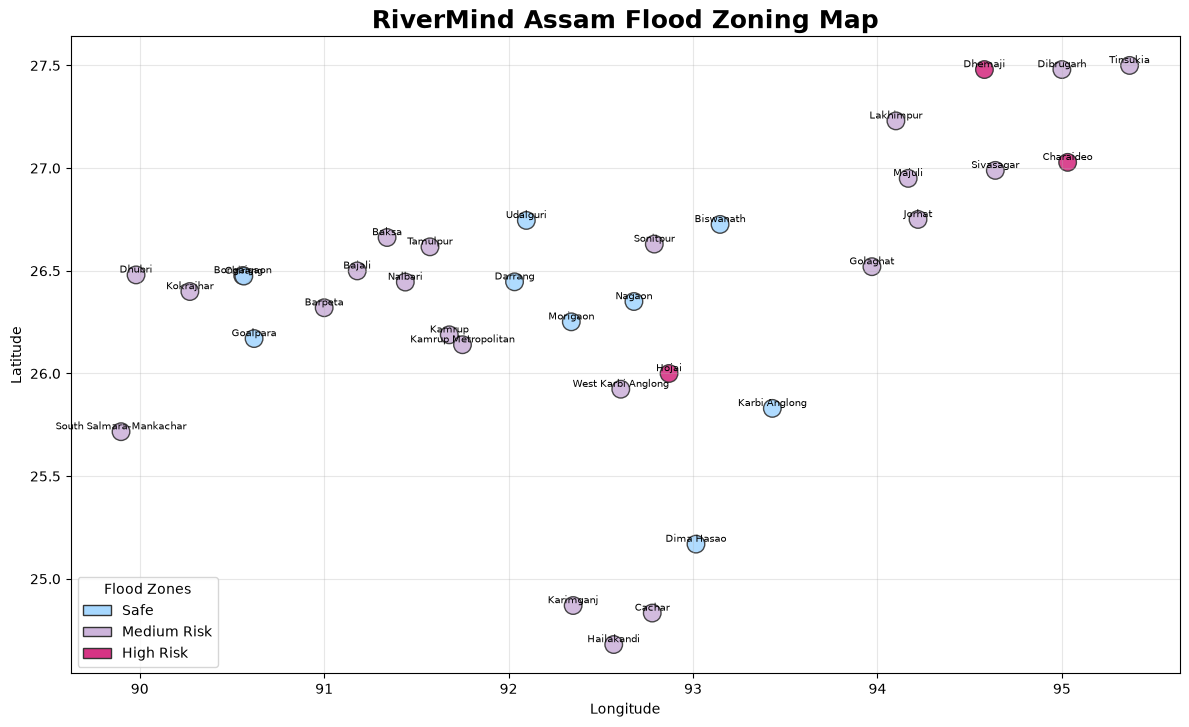

Static flood map saved to:
C:\Users\Aadya\OneDrive\Desktop\rainfall_prediction\outputs\assam_flood_zoning_map.png


In [13]:
# CELL 11 — Generate Static Flood Map
#
# If an Assam district boundary file is available, it is used.
# Otherwise, the notebook creates a coordinate-based district map.

boundary_candidates = [
    PROJECT_FOLDER / "assam_district_boundaries.geojson",
    PROJECT_FOLDER / "assam_district_boundaries.shp",
    PROJECT_FOLDER / "assam_district_boundaries.gpkg",
    PROJECT_FOLDER / "Assam_District_Boundaries.geojson",
    PROJECT_FOLDER / "Assam_District_Boundaries.shp",
    PROJECT_FOLDER / "Assam_District_Boundaries.gpkg"
]

boundary_file = None

for candidate in boundary_candidates:
    if candidate.exists():
        boundary_file = candidate
        break

fig, ax = plt.subplots(
    figsize=(12, 12)
)

if boundary_file is not None:
    boundary_gdf = gpd.read_file(
        boundary_file
    )
    
    possible_name_columns = [
        "District",
        "district",
        "DISTRICT",
        "NAME_2",
        "NAME"
    ]
    
    boundary_name_column = None
    
    for column in possible_name_columns:
        if column in boundary_gdf.columns:
            boundary_name_column = column
            break
    
    if boundary_name_column is not None:
        boundary_gdf["Boundary_District"] = (
            boundary_gdf[boundary_name_column]
            .astype(str)
            .str.strip()
        )
        
        boundary_gdf["Normalized_District"] = (
            boundary_gdf["Boundary_District"]
            .apply(normalize_district_name)
        )
        
        merged_df["Normalized_District"] = (
            merged_df["District"]
            .apply(normalize_district_name)
        )
        
        boundary_gdf = boundary_gdf.merge(
            merged_df[
                [
                    "Normalized_District",
                    "Flood_Zone",
                    "Zone_Color",
                    "Flood_Risk_Score"
                ]
            ],
            on="Normalized_District",
            how="left"
        )
        
        boundary_gdf["Zone_Color"] = (
            boundary_gdf["Zone_Color"]
            .fillna(SAFE_COLOR)
        )
        
        boundary_gdf.plot(
            ax=ax,
            color=boundary_gdf["Zone_Color"],
            edgecolor="#333333",
            linewidth=0.7
        )
        
        for _, row in boundary_gdf.iterrows():
            if (
                row.geometry is not None and
                not row.geometry.is_empty
            ):
                label_point = (
                    row.geometry.representative_point()
                )
                
                ax.text(
                    label_point.x,
                    label_point.y,
                    row["Boundary_District"],
                    fontsize=6,
                    ha="center",
                    va="center"
                )
        
        ax.set_axis_off()
    else:
        print(
            "Boundary file found, but district column was not identified."
        )
        boundary_file = None

if boundary_file is None:
    point_gdf = gpd.GeoDataFrame(
        merged_df.copy(),
        geometry=gpd.points_from_xy(
            merged_df["Longitude"],
            merged_df["Latitude"]
        ),
        crs="EPSG:4326"
    )
    
    point_gdf.plot(
        ax=ax,
        color=point_gdf["Zone_Color"],
        edgecolor="#333333",
        markersize=160,
        alpha=0.9
    )
    
    for _, row in point_gdf.iterrows():
        ax.text(
            row.geometry.x,
            row.geometry.y,
            row["District"],
            fontsize=7,
            ha="center",
            va="bottom"
        )
    
    ax.set_xlabel("Longitude")
    ax.set_ylabel("Latitude")
    ax.grid(True, alpha=0.3)

ax.set_title(
    "RiverMind Assam Flood Zoning Map",
    fontsize=18,
    fontweight="bold"
)

legend_items = [
    Patch(
        facecolor=SAFE_COLOR,
        edgecolor="#333333",
        label="Safe"
    ),
    Patch(
        facecolor=MEDIUM_COLOR,
        edgecolor="#333333",
        label="Medium Risk"
    ),
    Patch(
        facecolor=HIGH_COLOR,
        edgecolor="#333333",
        label="High Risk"
    )
]

ax.legend(
    handles=legend_items,
    title="Flood Zones",
    loc="lower left"
)

plt.tight_layout()

plt.savefig(
    PNG_MAP_FILE,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Static flood map saved to:")
print(PNG_MAP_FILE)

In [14]:
# CELL 12 — Generate Flood Summary Table

summary_df = merged_df[
    [
        "District",
        "Rainfall_24h_mm",
        "Flood_Risk_Score",
        "Flood_Zone"
    ]
].copy()

summary_df = summary_df.rename(
    columns={
        "Rainfall_24h_mm": "Rainfall_mm"
    }
)

summary_df = summary_df.sort_values(
    "Flood_Risk_Score",
    ascending=False
).reset_index(drop=True)

# Save summary Excel file.
summary_df.to_excel(
    SUMMARY_FILE,
    index=False
)

# Save complete daily dataset.
merged_df.to_csv(
    TODAY_DATASET_FILE,
    index=False,
    na_rep=""
)

print("Summary file saved to:")
print(SUMMARY_FILE)

print("\nComplete daily risk dataset saved to:")
print(TODAY_DATASET_FILE)

display(summary_df)

Summary file saved to:
C:\Users\Aadya\OneDrive\Desktop\rainfall_prediction\outputs\flood_summary_today.xlsx

Complete daily risk dataset saved to:
C:\Users\Aadya\OneDrive\Desktop\rainfall_prediction\outputs\flood_risk_dataset_today.csv


,District,Rainfall_mm,Flood_Risk_Score,Flood_Zone
0,Dhemaji,7.8,96.54,High Risk
1,Hojai,7.0,81.97,High Risk
2,Charaideo,4.1,66.29,High Risk
3,Lakhimpur,1.8,48.47,Medium Risk
4,Bajali,1.2,46.78,Medium Risk
5,Golaghat,2.9,46.65,Medium Risk
6,Tinsukia,2.3,45.83,Medium Risk
7,Sonitpur,1.1,45.38,Medium Risk
8,Tamulpur,1.3,44.33,Medium Risk
9,Jorhat,1.4,43.76,Medium Risk


In [15]:
# CELL 13 — Display Top 10 High-Risk Districts

top_10_df = summary_df.head(10).copy()

top_10_df.index = np.arange(
    1,
    len(top_10_df) + 1
)

print("Top 10 districts by flood-risk score:")

display(
    top_10_df.style.format(
        {
            "Rainfall_mm": "{:.2f}",
            "Flood_Risk_Score": "{:.2f}"
        }
    )
)

Top 10 districts by flood-risk score:


,District,Rainfall_mm,Flood_Risk_Score,Flood_Zone
1,Dhemaji,7.80,96.54,High Risk
2,Hojai,7.00,81.97,High Risk
3,Charaideo,4.10,66.29,High Risk
4,Lakhimpur,1.80,48.47,Medium Risk
5,Bajali,1.20,46.78,Medium Risk
6,Golaghat,2.90,46.65,Medium Risk
7,Tinsukia,2.30,45.83,Medium Risk
8,Sonitpur,1.10,45.38,Medium Risk
9,Tamulpur,1.30,44.33,Medium Risk
10,Jorhat,1.40,43.76,Medium Risk


In [16]:
# CELL 14 — Daily Automation Function
#
# This function uses the latest Open-Meteo data.
# It updates rainfall history, recalculates risk, and saves outputs.

def update_daily_rainfall():
    global TODAY
    global today_rainfall_df
    global rainfall_history_df
    global merged_df
    global summary_df
    global assam_map
    
    print("Starting RiverMind daily update...")
    
    # Refresh today's date.
    TODAY = datetime.now().strftime("%Y-%m-%d")
    
    # Fetch fresh Open-Meteo rainfall.
    today_rainfall_df = fetch_open_meteo_rainfall()
    
    # Load old history.
    if RAINFALL_HISTORY_FILE.exists():
        rainfall_history_df = pd.read_csv(
            RAINFALL_HISTORY_FILE
        )
    else:
        rainfall_history_df = pd.DataFrame(
            columns=history_columns
        )
    
    for column in history_columns:
        if column not in rainfall_history_df.columns:
            rainfall_history_df[column] = np.nan
    
    rainfall_history_df = rainfall_history_df[
        history_columns
    ].copy()
    
    rainfall_history_df["District"] = (
        rainfall_history_df["District"]
        .astype(str)
        .str.strip()
    )
    
    rainfall_history_df["Date"] = pd.to_datetime(
        rainfall_history_df["Date"],
        errors="coerce"
    ).dt.strftime("%Y-%m-%d")
    
    # Create complete records for all districts.
    today_complete_df = district_df[
        ["District"]
    ].copy()
    
    today_complete_df["Date"] = TODAY
    
    today_complete_df = today_complete_df.merge(
        today_rainfall_df,
        on=["District", "Date"],
        how="left"
    )
    
    today_complete_df = today_complete_df[
        history_columns
    ]
    
    # Replace today's old records.
    rainfall_history_df = rainfall_history_df[
        rainfall_history_df["Date"] != TODAY
    ]
    
    rainfall_history_df = pd.concat(
        [
            rainfall_history_df,
            today_complete_df
        ],
        ignore_index=True
    )
    
    rainfall_history_df = rainfall_history_df.drop_duplicates(
        subset=["District", "Date"],
        keep="last"
    )
    
    rainfall_history_df = rainfall_history_df.sort_values(
        ["Date", "District"]
    ).reset_index(drop=True)
    
    rainfall_history_df.to_csv(
        RAINFALL_HISTORY_FILE,
        index=False,
        na_rep=""
    )
    
    # Prepare today's merged data.
    today_rainfall_for_merge = rainfall_history_df[
        rainfall_history_df["Date"] == TODAY
    ].copy()
    
    merged_df = district_df.merge(
        today_rainfall_for_merge,
        on="District",
        how="left"
    )
    
    merged_df["Date"] = merged_df["Date"].fillna(TODAY)
    
    # Prepare date and rainfall fields for rolling calculations.
    rainfall_history_df["Date_As_Datetime"] = pd.to_datetime(
        rainfall_history_df["Date"],
        errors="coerce"
    )
    
    rainfall_history_df["Rainfall_mm"] = pd.to_numeric(
        rainfall_history_df["Rainfall_mm"],
        errors="coerce"
    )
    
    # Recalculate rolling rainfall.
    merged_df["Rainfall_24h_mm"] = merged_df[
        "District"
    ].apply(
        lambda district: rainfall_total_for_previous_days(
            district,
            TODAY,
            1
        )
    )
    
    merged_df["Rainfall_3day_mm"] = merged_df[
        "District"
    ].apply(
        lambda district: rainfall_total_for_previous_days(
            district,
            TODAY,
            3
        )
    )
    
    merged_df["Rainfall_7day_mm"] = merged_df[
        "District"
    ].apply(
        lambda district: rainfall_total_for_previous_days(
            district,
            TODAY,
            7
        )
    )
    
    merged_df["Rainfall_30day_mm"] = merged_df[
        "District"
    ].apply(
        lambda district: rainfall_total_for_previous_days(
            district,
            TODAY,
            30
        )
    )
    
    # Recalculate terrain risks.
    merged_df["Elevation_Risk"] = normalize_series(
        merged_df["Elevation_m"],
        invert=True
    )
    
    merged_df["River_Distance_Risk"] = normalize_series(
        merged_df["Distance_to_River_km"],
        invert=True
    )
    
    # Recalculate normalized rainfall.
    merged_df["Rainfall24_Normalized"] = normalize_series(
        merged_df["Rainfall_24h_mm"]
    )
    
    merged_df["Rainfall3Day_Normalized"] = normalize_series(
        merged_df["Rainfall_3day_mm"]
    )
    
    # Recalculate flood score.
    merged_df["Flood_Risk_Score"] = (
        0.35 * merged_df["Rainfall24_Normalized"] +
        0.25 * merged_df["Rainfall3Day_Normalized"] +
        0.20 * merged_df["Elevation_Risk"] +
        0.20 * merged_df["River_Distance_Risk"]
    ) * 100
    
    merged_df["Flood_Risk_Score"] = (
        merged_df["Flood_Risk_Score"]
        .clip(0, 100)
        .round(2)
    )
    
    # Reassign flood zones.
    merged_df["Flood_Zone"] = merged_df[
        "Flood_Risk_Score"
    ].apply(assign_flood_zone)
    
    merged_df["Zone_Color"] = merged_df[
        "Flood_Zone"
    ].map(ZONE_COLORS)
    
    # Save updated datasets.
    merged_df.to_csv(
        DISTRICT_OUTPUT_FILE,
        index=False,
        na_rep=""
    )
    
    merged_df.to_csv(
        TODAY_DATASET_FILE,
        index=False,
        na_rep=""
    )
    
    summary_df = merged_df[
        [
            "District",
            "Rainfall_24h_mm",
            "Flood_Risk_Score",
            "Flood_Zone"
        ]
    ].rename(
        columns={
            "Rainfall_24h_mm": "Rainfall_mm"
        }
    ).sort_values(
        "Flood_Risk_Score",
        ascending=False
    )
    
    summary_df.to_excel(
        SUMMARY_FILE,
        index=False
    )
    
    # Regenerate the interactive map.
    assam_map = folium.Map(
        location=[26.2, 92.9],
        zoom_start=7,
        tiles="CartoDB positron",
        control_scale=True
    )
    
    assam_map.get_root().html.add_child(
        folium.Element(title_html)
    )
    
    for _, row in merged_df.iterrows():
        latitude = pd.to_numeric(
            row["Latitude"],
            errors="coerce"
        )
        
        longitude = pd.to_numeric(
            row["Longitude"],
            errors="coerce"
        )
        
        if pd.isna(latitude) or pd.isna(longitude):
            continue
        
        rainfall_24h = row["Rainfall_24h_mm"]
        rainfall_3day = row["Rainfall_3day_mm"]
        score = row["Flood_Risk_Score"]
        
        rainfall_24h_text = (
            "NA"
            if pd.isna(rainfall_24h)
            else f"{rainfall_24h:.2f} mm"
        )
        
        rainfall_3day_text = (
            "NA"
            if pd.isna(rainfall_3day)
            else f"{rainfall_3day:.2f} mm"
        )
        
        score_text = (
            "NA"
            if pd.isna(score)
            else f"{score:.2f}/100"
        )
        
        popup_html = f"""
        <div style="width: 270px;">
            <h4>{row['District']}</h4>
            <b>Today's Rainfall:</b> {rainfall_24h_text}<br>
            <b>3-Day Rainfall:</b> {rainfall_3day_text}<br>
            <b>Elevation:</b> {row['Elevation_m']} m<br>
            <b>Closest River:</b> {row['Closest_River']}<br>
            <b>Distance from River:</b>
            {row['Distance_to_River_km']} km<br>
            <b>Flood Risk Score:</b> {score_text}<br>
            <b>Flood Zone:</b> {row['Flood_Zone']}
        </div>
        """
        
        folium.CircleMarker(
            location=[latitude, longitude],
            radius=9,
            color=row["Zone_Color"],
            fill=True,
            fill_color=row["Zone_Color"],
            fill_opacity=0.85,
            weight=2,
            popup=folium.Popup(
                popup_html,
                max_width=330
            ),
            tooltip=(
                f"{row['District']} - "
                f"{row['Flood_Zone']}"
            )
        ).add_to(assam_map)
    
    assam_map.get_root().html.add_child(
        folium.Element(legend_html)
    )
    
    assam_map.save(HTML_MAP_FILE)
    
    print("RiverMind daily update completed.")
    print("Rainfall history:", RAINFALL_HISTORY_FILE)
    print("District dataset:", DISTRICT_OUTPUT_FILE)
    print("Daily dataset:", TODAY_DATASET_FILE)
    print("Summary:", SUMMARY_FILE)
    print("Interactive map:", HTML_MAP_FILE)
    
    return merged_df


# Run one update now to test the function.
updated_dataset = update_daily_rainfall()

display(
    updated_dataset.head()
)

Starting RiverMind daily update...
Fetching today's rainfall from Open-Meteo...
API error for Darrang: 503 Server Error: Service Unavailable for url: https://api.open-meteo.com/v1/forecast?latitude=26.4463&longitude=92.0322&daily=precipitation_sum&timezone=Asia%2FKolkata&forecast_days=1&past_days=0
API error for Dhemaji: 503 Server Error: Service Unavailable for url: https://api.open-meteo.com/v1/forecast?latitude=27.48&longitude=94.58&daily=precipitation_sum&timezone=Asia%2FKolkata&forecast_days=1&past_days=0
API error for Dhubri: 503 Server Error: Service Unavailable for url: https://api.open-meteo.com/v1/forecast?latitude=26.48&longitude=89.98&daily=precipitation_sum&timezone=Asia%2FKolkata&forecast_days=1&past_days=0
API error for Goalpara: 503 Server Error: Service Unavailable for url: https://api.open-meteo.com/v1/forecast?latitude=26.17&longitude=90.62&daily=precipitation_sum&timezone=Asia%2FKolkata&forecast_days=1&past_days=0
API error for Hojai: 503 Server Error: Service Unava

,District,Latitude,Longitude,Elevation_m,Nearest_River,Distance_to_River_km,River_Type,Closest_River,Date,Rainfall_mm,Normal_Rainfall_mm,Departure_Percent,Rainfall_24h_mm,Rainfall_3day_mm,Rainfall_7day_mm,Rainfall_30day_mm,Elevation_Risk,River_Distance_Risk,Rainfall24_Normalized,Rainfall3Day_Normalized,Flood_Risk_Score,Flood_Zone,Zone_Color
0,Bajali,26.4994,91.1793,43,Pagladia River,5,North Bank Tributary,Pagladia River,2026-09-28,1.2,NaN,NaN,1.2,1.2,1.2,1.2,0.968520,0.909091,0.292683,0.292683,55.11,Medium Risk,#CDB4DB
1,Baksa,26.6620,91.3411,52,Manas River,8,North Bank Tributary,Manas River,2026-09-28,0.5,NaN,NaN,0.5,0.5,0.5,0.5,0.959077,0.818182,0.121951,0.121951,42.86,Medium Risk,#CDB4DB
2,Barpeta,26.3200,91.0000,35,Brahmaputra River,12,Main Stem,Brahmaputra River,2026-09-28,0.9,NaN,NaN,0.9,0.9,0.9,0.9,0.976915,0.696970,0.219512,0.219512,46.65,Medium Risk,#CDB4DB
3,Biswanath,26.7258,93.1466,69,Brahmaputra River,15,Main Stem,Brahmaputra River,2026-09-28,0.5,NaN,NaN,0.5,0.5,0.5,0.5,0.941238,0.606061,0.121951,0.121951,38.26,Medium Risk,#CDB4DB
4,Bongaigaon,26.4769,90.5583,63,Brahmaputra River,10,Main Stem,Brahmaputra River,2026-09-28,0.2,NaN,NaN,0.2,0.2,0.2,0.2,0.947534,0.757576,0.048780,0.048780,37.03,Medium Risk,#CDB4DB


In [17]:
# CELL 15 — Automatic 24-Hour Update
#
# The notebook itself does not need to stay open.
# For Windows Task Scheduler:
#
# 1. Export this notebook as a Python script from VS Code.
#
# 2. Save the exported script inside:
#    C:\Users\Aadya\OneDrive\Desktop\rainfall_prediction
#
# 3. Create a file named run_rivermind.bat with:
#
#    @echo off
#    cd /d "C:\Users\Aadya\OneDrive\Desktop\rainfall_prediction"
#    python RiverMind_Assam_Flood_Monitoring.py
#
# 4. Open Windows Task Scheduler.
#
# 5. Choose "Create Basic Task".
#
# 6. Set the trigger to Daily.
#
# 7. Set the action to "Start a program".
#
# 8. Program:
#    C:\Windows\System32\cmd.exe
#
# 9. Arguments:
#    /c "C:\Users\Aadya\OneDrive\Desktop\rainfall_prediction\run_rivermind.bat"
#
# 10. Start in:
#     C:\Users\Aadya\OneDrive\Desktop\rainfall_prediction
#
# The exported Python script should end with:
#
# if __name__ == "__main__":
#     update_daily_rainfall()
#
# When Task Scheduler runs it, the script will:
# - Call Open-Meteo
# - Update rainfall history
# - Recalculate flood risk
# - Save CSV files
# - Save the Excel summary
# - Regenerate the interactive HTML map

print("Automatic update instructions are included in the comments above.")
print("Open-Meteo daily API integration is ready.")

Automatic update instructions are included in the comments above.
Open-Meteo daily API integration is ready.
